# Implementation of the ROC and AUC Curve

- ROC: Receiver Operating Characteristic: Focus on the graph
- AUC: Area Under the Curve: How well the two classes are separated.

The rules

- AUC -> 0.5: Random Guessing
- AUC -> 1: Perfectly classified
- AUC -> below 0.5: Indicate performance worse than random guessing




The formula for ROC is:

$$
TPR = \frac{TP}{TP + FN}
$$


and,
$$
FPR = \frac{FP}{FP + TN}
$$

Where,

- TP -> True Positive: Actual Positive, Predicted Positive
- FP -> False Positive: Actual 

AUC: 0.9226936026936027


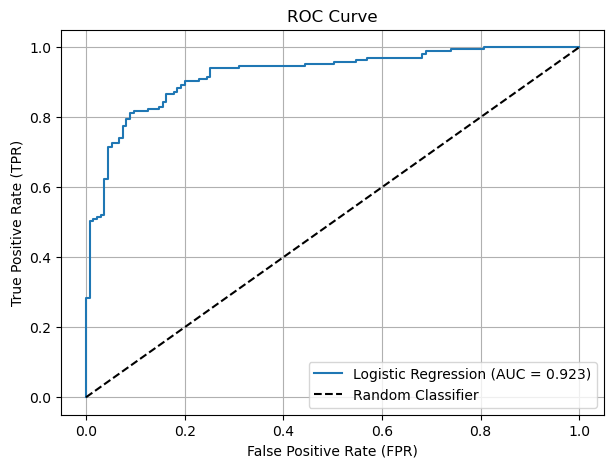

In [4]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score

# Create sample binary classification data
X, y = make_classification(
    n_samples=1000,
    n_features=10,
    n_classes=2,
    random_state=42
)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Train model
model = LogisticRegression()
model.fit(X_train, y_train)

# Get probability of positive class
y_prob = model.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate AUC
auc = roc_auc_score(y_test, y_prob)

print("AUC:", auc)

# Plot ROC curve
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.3f})")

# Random classifier reference line
plt.plot([0, 1], [0, 1], "k--", label="Random Classifier")

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

By visualising the ROC and AUC Curve, the AUC of logistic Regression is 0.923 which means, the model has high ability to distinguish between the positive and negative classes.